In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error
from __future__ import print_function

In [2]:
loc = 'C:/Users/LAPTOP/Downloads/yellow_tripdata.csv'
tip_resp = pd.read_csv(loc)
tip_resp

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41197,2,1,16.94,2,1,132,164,1,70.0,0.5,6.94,1,5.00
41198,2,4,19.83,2,1,132,166,1,70.0,0.5,6.94,1,8.00
41199,2,1,17.31,2,1,132,137,1,70.0,0.5,6.94,1,8.00
41200,2,1,17.28,2,1,132,233,1,70.0,0.5,6.94,1,16.19


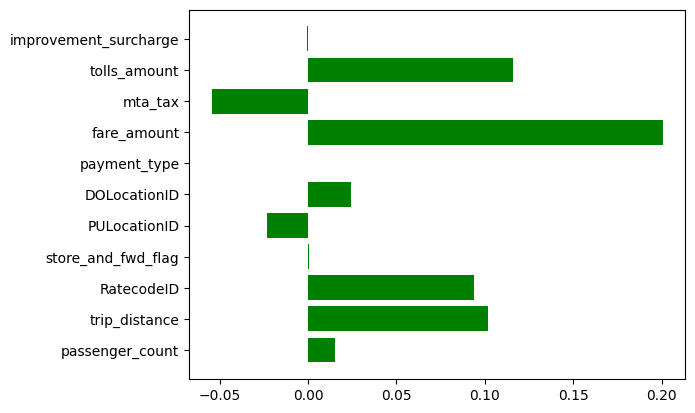

In [3]:
correlation_values = tip_resp.corr()['tip_amount'].drop('tip_amount')
plt.barh(correlation_values.index, correlation_values.values, color='green')
plt.rcParams["figure.figsize"] = (10,10)
plt.show()

In [60]:
tip_resp.corr()['tip_amount'].drop('tip_amount')

VendorID                      NaN
passenger_count          0.015081
trip_distance            0.101819
RatecodeID               0.094075
store_and_fwd_flag       0.000320
PULocationID            -0.023086
DOLocationID             0.024348
payment_type                  NaN
fare_amount              0.200638
mta_tax                 -0.054488
tolls_amount             0.116172
improvement_surcharge   -0.000727
Name: tip_amount, dtype: float64

In [39]:
tips = tip_resp[['tip_amount']].values.astype('float32')
data = tip_resp.drop(['tip_amount'], axis=1).values
data = normalize(data, axis=1, norm='l1',copy=False)

array([[0.00501165, 0.00250583, 0.04417771, ..., 0.00125291, 0.01739043,
        0.00250583],
       [0.00422869, 0.00211434, 0.04127199, ..., 0.00105717, 0.01467355,
        0.00211434],
       [0.0070609 , 0.00353045, 0.06287732, ..., 0.00176523, 0.02450132,
        0.00353045],
       ...,
       [0.00537996, 0.00268998, 0.04656355, ..., 0.00134499, 0.01866846,
        0.00268998],
       [0.00427606, 0.00213803, 0.03694518, ..., 0.00106902, 0.01483794,
        0.00213803],
       [0.00494731, 0.00247366, 0.04160689, ..., 0.00123683, 0.01716717,
        0.00247366]], shape=(41202, 12))

In [58]:
train_data, test_data, train_tips, test_tips = train_test_split(data, tips, test_size=0.2, random_state=42)

In [59]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
treegressor = DecisionTreeRegressor(criterion='squared_error', max_depth=8, random_state=36)
treegressor.fit(train_data, train_tips)
pred_tips = treegressor.predict(test_data)
print(f'{(mean_squared_error(pred_tips, test_tips))}')

25.601012706057105
